<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drought_Severity_Bar_Chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

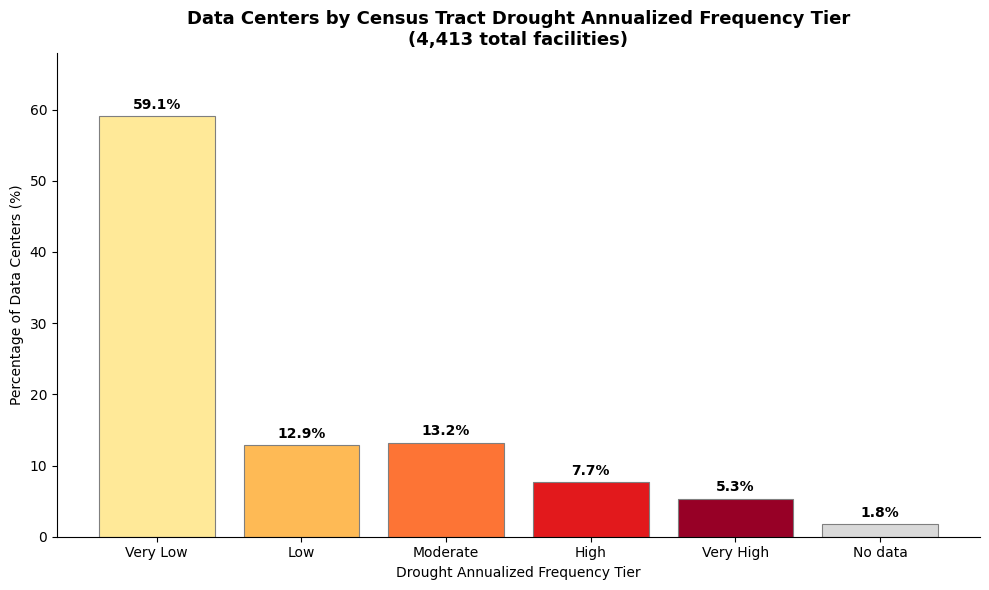

In [1]:
# Run once
# !pip install geopandas matplotlib numpy pandas shapely

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Load & clean census-tract-level drought data ----
gdf = gpd.read_file("/content/Census_Tract.shp")

# Make sure drought values are numeric
gdf["DRGT_AFREQ"] = pd.to_numeric(
    gdf["DRGT_AFREQ"],
    errors="coerce"
)

# Make sure coordinates are latitude/longitude first
gdf = gdf.to_crs(epsg=4326)

# Remove U.S. territories only
territories = [
    "Puerto Rico",
    "Virgin Islands",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands"
]
gdf = gdf[~gdf["STATE"].isin(territories)].copy()

# ---- Build the same 5-tier drought scale used on the map ----
# (2nd-98th percentile range split into 5 equal-width bins)
drought_values = gdf["DRGT_AFREQ"].dropna()
vmin = drought_values.quantile(0.02)
vmax = drought_values.quantile(0.98)
bins = np.linspace(vmin, vmax, 6)

gdf["drought_bin"] = pd.cut(
    gdf["DRGT_AFREQ"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Clamp out-of-range values into the first/last tier
gdf.loc[gdf["DRGT_AFREQ"] < vmin, "drought_bin"] = 0
gdf.loc[gdf["DRGT_AFREQ"] > vmax, "drought_bin"] = 4

# ---- Load data center / facility locations ----
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

total_facility_count = len(facilities)

# This map works at the census-tract level, so facilities can't be
# matched by county FIPS the way the other bar charts do. Instead,
# build a point for each facility from its lat/lon and match it to a
# tract spatially. Facilities missing coordinates, or whose point
# doesn't land inside any tract, end up in "No data" below.
facility_points = facilities[
    facilities["latitude"].notna() & facilities["longitude"].notna()
].copy()

facility_points = gpd.GeoDataFrame(
    facility_points,
    geometry=gpd.points_from_xy(facility_points["longitude"], facility_points["latitude"]),
    crs="EPSG:4326"
)

# ---- Match each facility to its tract's drought tier ----
facility_tract_match = gpd.sjoin(
    facility_points,
    gdf[["geometry", "drought_bin"]],
    how="left",
    predicate="within"
)

# Drought severity tier names & colors, low -> high (same as map legend)
tier_names = ["Very Low", "Low", "Moderate", "High", "Very High"]
tier_colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
missing_color = "#D9D9D9"

# Count data centers in each tier
counts = [int((facility_tract_match["drought_bin"] == i).sum()) for i in range(5)]

# Everything else: no coordinates at all, or a point that didn't fall
# inside any tract
no_data_count = total_facility_count - sum(counts)

labels = tier_names + ["No data"]
values = counts + [no_data_count]
colors = list(tier_colors) + [missing_color]

# Convert counts to a percentage of all facilities
percentages = [v / total_facility_count * 100 for v in values]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8
)

# Percentage label above each bar
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    f"Data Centers by Census Tract Drought Annualized Frequency Tier\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Drought Annualized Frequency Tier")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()